In [1]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sb
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error

In [2]:
#import dataset 
import os
import openpyxl
pwd = os.getcwd()
dataset = pd.read_excel(pwd + "/data/DATA.xlsx")
dataset_copy = dataset.copy()
dataset_copy.head(4)

,Datetime,Date,Year,Month,Day,Time,Hour,Temperature,Holiday,Daytype,Frequency of use [Cooker],Frequency of use [Light],Frequency of use [Laptop],Frequency of use [Kettle],Frequency of use [Fan],Frequency of use [Ipod/Tab/Phone],Frequency of use in a day [Iron],Power
0,2022-09-01 00:00:00,2022-09-01,2022,9,1,00:00,0,23.82,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
1,2022-09-01 01:00:00,2022-09-01,2022,9,1,01:00,1,23.68,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
2,2022-09-01 02:00:00,2022-09-01,2022,9,1,02:00,2,23.61,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN
3,2022-09-01 03:00:00,2022-09-01,2022,9,1,03:00,3,23.56,1,Thursday,Low,Medium,Medium,Low,High,Medium,Low,NaN


In [3]:
#run when modeling
dataset_copy.drop(['Time', 'Date', 'Frequency of use [Cooker]',	'Frequency of use [Light]',	'Frequency of use [Laptop]','Frequency of use [Kettle]',	'Frequency of use [Fan]'	,'Frequency of use [Ipod/Tab/Phone]',	'Frequency of use in a day [Iron]'	], inplace=True, axis=1)

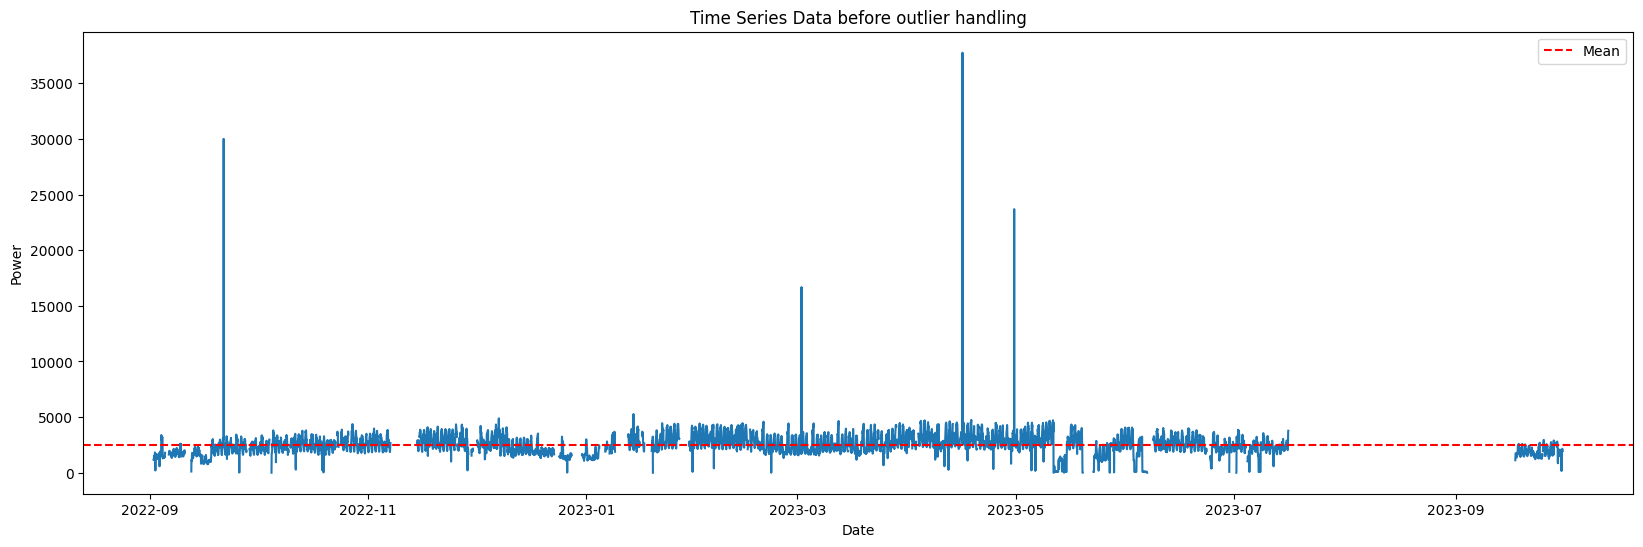

In [4]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
dataset_copy.set_index('Datetime', inplace=True)
plt.plot(dataset_copy['Power'])
plt.xlabel('Date')
plt.ylabel('Power')
plt.title('Time Series Data before outlier handling')
plt.axhline(y=dataset['Power'].mean(), color='r', linestyle='--', label='Mean')
plt.legend()
plt.show()

In [5]:
#handling outlier using IQR - interquantile range
upper = dataset_copy['Power'].quantile(0.75)
lower = dataset_copy['Power'].quantile(0.25)
IQR = upper - lower
max_threshold = upper + (1.5 * IQR)
min_threshold = lower - (1.5 * IQR)

In [6]:
#capping outlier
dataset_copy['Power'] = np.where(dataset_copy['Power']>max_threshold, max_threshold, np.where(dataset_copy['Power']<min_threshold, min_threshold,dataset_copy['Power'] ))

In [7]:
#fill missing value with mean
mean = dataset_copy['Power'].mean()
dataset_copy['Power']= dataset_copy['Power'].fillna(mean)
#dataset_copy.dropna(inplace=True)

In [8]:
# converts to numpy array format - without survey
X = dataset_copy.iloc[:,:-1].values
Y = dataset_copy.iloc[:,7:].values

In [9]:
#encoding categorical data - without survey
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [6])], remainder = 'passthrough')
X =  np.array(ct.fit_transform(X))

In [10]:
#splitting Dataset into training and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [11]:
#splitting training into validation and train
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [12]:
#Data normalization - without survey
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train[:,11] = sc.fit_transform(X_train[:,11].reshape(-1, 1)).flatten()
X_test[:,11] = sc.fit_transform(X_test[:,11].reshape(-1, 1)).flatten()
X_val[:,11] = sc.fit_transform(X_val[:,11].reshape(-1, 1)).flatten()

In [13]:
y_train = y_train.flatten()
y_test = y_test.flatten()
y_val = y_val.flatten()

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
# Import libraries
from xgboost import XGBRegressor

# Create the XGBoost model
model = XGBRegressor(n_estimators=320, learning_rate=0.2, max_depth = 6,  early_stopping_rounds=50)  # You can adjust these hyperparameters

# Train the model
model.fit(X_train, y_train, eval_set=[(X_train, y_train),(X_val, y_val)],  verbose=True)

# Make predictions on the testing set
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_pred = model.predict(X_test)

[0]	validation_0-rmse:649.95452	validation_1-rmse:669.70022
[1]	validation_0-rmse:607.24924	validation_1-rmse:628.23134
[2]	validation_0-rmse:578.67448	validation_1-rmse:601.60197
[3]	validation_0-rmse:555.96490	validation_1-rmse:581.07755
[4]	validation_0-rmse:538.51804	validation_1-rmse:566.04303
[5]	validation_0-rmse:525.59757	validation_1-rmse:555.02935
[6]	validation_0-rmse:508.66839	validation_1-rmse:541.60325
[7]	validation_0-rmse:496.73376	validation_1-rmse:530.00363
[8]	validation_0-rmse:483.87564	validation_1-rmse:519.71669
[9]	validation_0-rmse:467.88836	validation_1-rmse:504.65904
[10]	validation_0-rmse:461.13982	validation_1-rmse:499.86298
[11]	validation_0-rmse:452.09884	validation_1-rmse:490.89285
[12]	validation_0-rmse:445.13691	validation_1-rmse:485.78752
[13]	validation_0-rmse:439.62881	validation_1-rmse:482.05238
[14]	validation_0-rmse:428.64911	validation_1-rmse:472.62940
[15]	validation_0-rmse:419.15516	validation_1-rmse:462.80414
[16]	validation_0-rmse:411.38721	v

In [15]:
# Evaluate the model
mse_train = mean_squared_error(y_train, y_train_pred)
mae_train = mean_absolute_error(y_train, y_train_pred)
mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

mse_val = mean_squared_error(y_val, y_val_pred)
mae_val = mean_absolute_error(y_val, y_val_pred)
mape_val = mean_absolute_percentage_error(y_val, y_val_pred)

mse_test = mean_squared_error(y_test, y_pred)
mae_test = mean_absolute_error(y_test, y_pred)
mape_test = mean_absolute_percentage_error(y_test, y_pred)

print("Mean Squared Error (MSE-TRAIN):", mse_train)
print("Mean Absolute Error (MAE-TRAIN):", mae_train)
print("Mean Absolute Percentage Error (MAPE-TRAIN):", mape_train)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-VAL):", mse_val)
print("Mean Absolute Error (MAE-VAL):", mae_val)
print("Mean Absolute Percentage Error (MAPE-VAL):", mape_val)
print("-------------------------------------------------")
print("Mean Squared Error (MSE-TEST):", mse_test)
print("Mean Absolute Error (MAE-TEST):", mae_test)
print("Mean Absolute Percentage Error (MAPE-TEST):", mape_test)

Mean Squared Error (MSE-TRAIN): 11281.657547320407
Mean Absolute Error (MAE-TRAIN): 73.09288486384078
Mean Absolute Percentage Error (MAPE-TRAIN): 0.03912601062830083
-------------------------------------------------
Mean Squared Error (MSE-VAL): 115535.63553716235
Mean Absolute Error (MAE-VAL): 219.24315173067322
Mean Absolute Percentage Error (MAPE-VAL): 0.12557993238882065
-------------------------------------------------
Mean Squared Error (MSE-TEST): 114796.75356904737
Mean Absolute Error (MAE-TEST): 217.9403061198066
Mean Absolute Percentage Error (MAPE-TEST): 0.11545922401225418


In [16]:
# Create a DataFrame to display actual and predicted values---xgboost
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("Actual vs Predicted:")
results_df.head(10)

Actual vs Predicted:


,Actual,Predicted
0,353.625000,802.714233
1,2116.000000,2245.569824
2,2511.614075,2553.173096
3,4049.000000,3319.042480
4,2409.000000,2262.253906
5,1425.000000,1627.653931
6,3475.000000,3406.169922
7,2511.614075,2654.459229
8,1909.000000,1861.038818
9,4110.000000,4241.838867


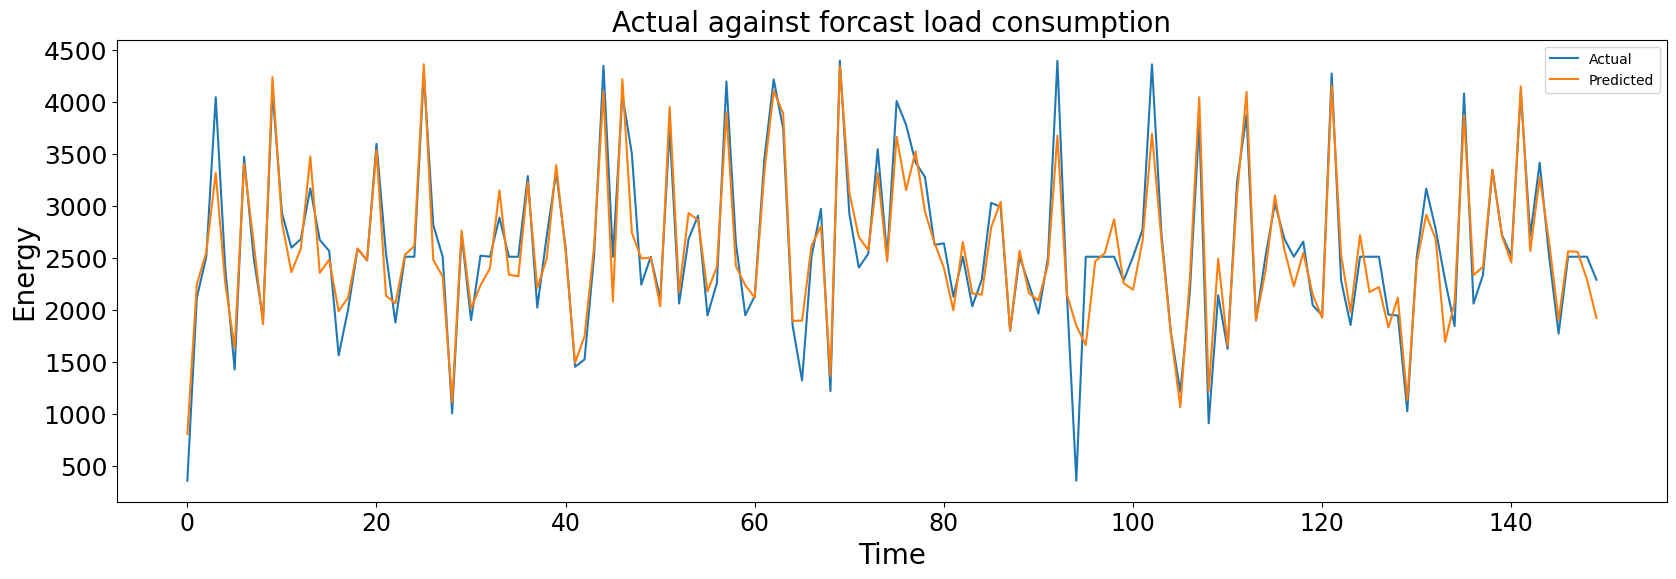

In [17]:
# Visual Inspection - Plot the data with missing values
plt.figure(figsize=(20, 6))
plt.plot(results_df['Actual'].head(150), label="Actual")
plt.plot(results_df['Predicted'].head(150), label="Predicted")
plt.title('Actual against forcast load consumption', fontsize=20)
plt.tick_params(axis='x', labelsize=17)
plt.tick_params(axis='y', labelsize=18)
plt.xlabel('Time', fontsize=20)
plt.ylabel('Energy', fontsize=20)
plt.legend()
plt.show()

In [18]:
# Assuming you already have a trained RandomForestRegressor model named 'rf_model'

# Get feature importances
feature_importances = model.feature_importances_
feature_names = ['Year','Month','Day','Hour','Daytype','Temperature','Holiday']
# Print feature names and importances (assuming you have a list of feature names 'feature_names')
for feature, importance in zip(feature_names, feature_importances):
    print(f"{feature}: {importance:.4f}")

Year: 0.0412
Month: 0.0400
Day: 0.1345
Hour: 0.0677
Daytype: 0.0281
Temperature: 0.0350
Holiday: 0.0281
